Dataset shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streami

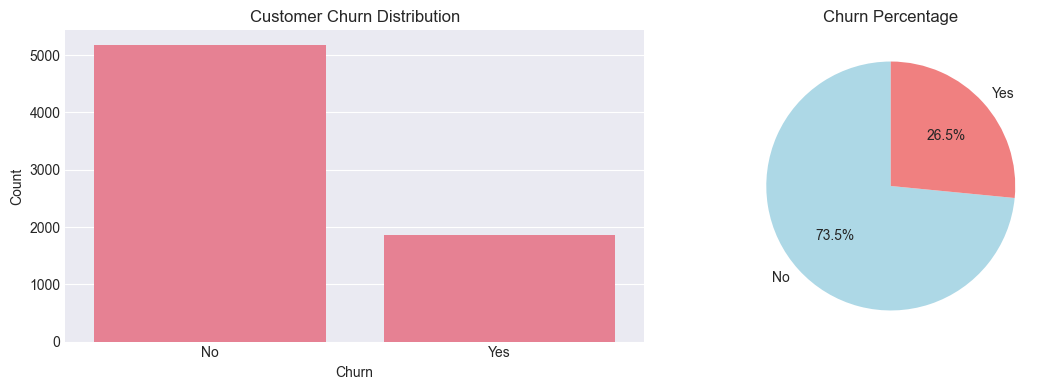

CATEGORICAL FEATURES ANALYSIS


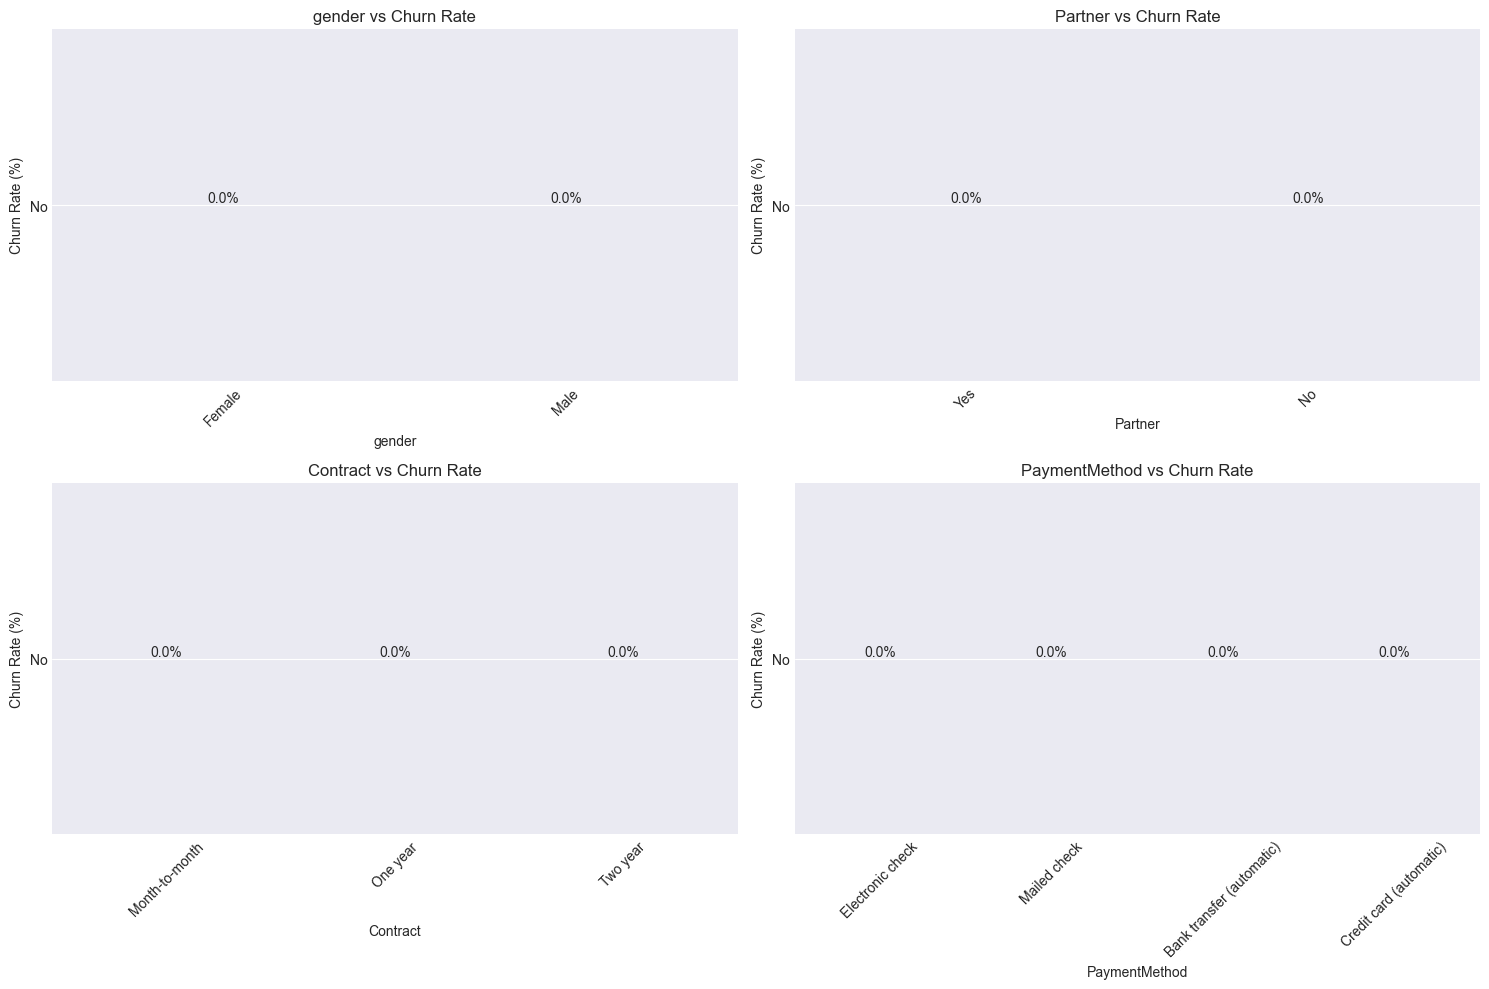

NUMERICAL FEATURES ANALYSIS

tenure:
  Mean - Churned: 17.98
  Mean - Retained: 37.57

MonthlyCharges:
  Mean - Churned: 74.44
  Mean - Retained: 61.27

TotalCharges:
  Mean - Churned: 1531.80
  Mean - Retained: 2555.34


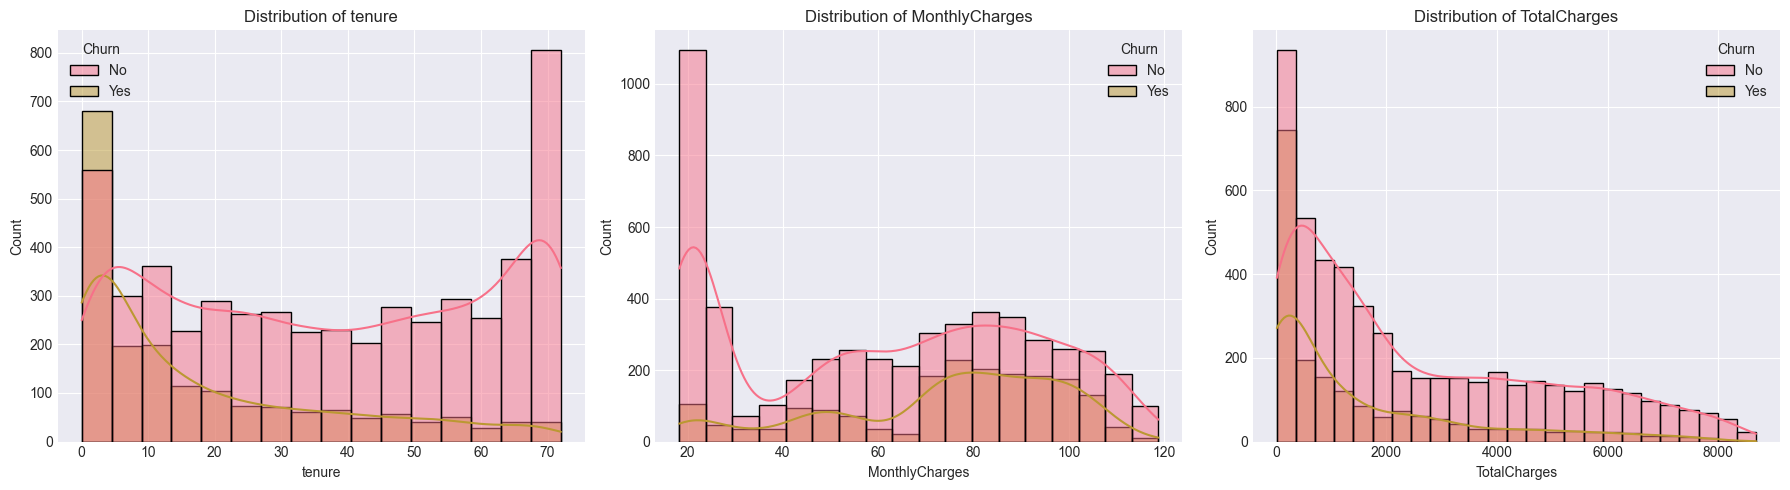

KEY INSIGHTS
1. Month-to-month contracts have 42.7% churn
   Two-year contracts have 2.8% churn

2. Customers with tenure ≤12 months: 47.4% churn
   Customers with tenure >12 months: 17.1% churn

SAVING PROCESSED DATA
Cleaned data saved to: data/processed/telco_churn_cleaned.csv
Cleaned shape: (7043, 21)


In [1]:
# CELL 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [ ]:
# CELL 2: Load data
df = pd.read_csv('data/raw/telco_churn.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

In [ ]:
# CELL 3: Basic info
print("="*50)
print("DATASET INFORMATION")
print("="*50)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe())

In [ ]:
# CELL 4: Target variable analysis
print("="*50)
print("TARGET VARIABLE: Churn")
print("="*50)
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(f"Total customers: {len(df)}")
print(f"Churned: {churn_counts['Yes']} ({churn_percentage['Yes']:.1f}%)")
print(f"Retained: {churn_counts['No']} ({churn_percentage['No']:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(data=df, x='Churn', ax=axes[0])
axes[0].set_title('Customer Churn Distribution')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index, 
            autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
axes[1].set_title('Churn Percentage')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 5: Analyze categorical features (simplified for Windows)
categorical_cols = ['gender', 'Partner', 'Contract', 'PaymentMethod']

print("="*50)
print("CATEGORICAL FEATURES ANALYSIS")
print("="*50)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_cols):
    # Calculate churn rate by category
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    
    # Plot
    sns.barplot(data=df, x=col, y='Churn', ax=axes[idx], 
                estimator=lambda x: (x == 'Yes').mean() * 100)
    axes[idx].set_title(f'{col} vs Churn Rate')
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].tick_params(axis='x', rotation=45)
    
    # Annotate with actual percentages
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.1f}%', 
                          (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [ ]:
# CELL 6: Analyze numerical features
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

print("="*50)
print("NUMERICAL FEATURES ANALYSIS")
print("="*50)

# Convert TotalCharges to numeric (it's stored as object)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(numerical_cols):
    # Distribution plot
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    
    # Calculate and print statistics
    print(f"\n{col}:")
    print(f"  Mean - Churned: {df[df['Churn'] == 'Yes'][col].mean():.2f}")
    print(f"  Mean - Retained: {df[df['Churn'] == 'No'][col].mean():.2f}")

plt.tight_layout()
plt.show()

# CELL 7: Key insights
print("="*50)
print("KEY INSIGHTS")
print("="*50)

# Insight 1: Contract type impact
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
print(f"1. Month-to-month contracts have {contract_churn['Month-to-month']:.1f}% churn")
print(f"   Two-year contracts have {contract_churn['Two year']:.1f}% churn")

# Insight 2: Tenure impact
short_tenure = df[df['tenure'] <= 12]['Churn'].apply(lambda x: 1 if x == 'Yes' else 0).mean() * 100
long_tenure = df[df['tenure'] > 12]['Churn'].apply(lambda x: 1 if x == 'Yes' else 0).mean() * 100
print(f"\n2. Customers with tenure ≤12 months: {short_tenure:.1f}% churn")
print(f"   Customers with tenure >12 months: {long_tenure:.1f}% churn")

# CELL 8: Save processed data
print("\n" + "="*50)
print("SAVING PROCESSED DATA")
print("="*50)

# Create cleaned version
df_clean = df.copy()
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(0, inplace=True)

# Save cleaned data
import os
os.makedirs('data/processed', exist_ok=True)
df_clean.to_csv('data/processed/telco_churn_cleaned.csv', index=False)
print("Cleaned data saved to: data/processed/telco_churn_cleaned.csv")
print(f"Cleaned shape: {df_clean.shape}")